# CYBER 207 | UNSW-NB15 EDA and Feature Engineering



**Class goal:** Explore network-flow data, create a few understandable features, and train one simple attack classifier.



By the end of this notebook, students will be able to:



- inspect rows, columns, data types, and missing values;

- use `describe()` to summarize numeric columns;

- draw bar charts, histograms, box plots, scatter plots, and a correlation heatmap;

- create total-bytes, total-packets, and bytes-per-packet features;

- prepare text columns with `pd.get_dummies()`;

- train and evaluate one decision tree.



> `label = 0` means normal traffic and `label = 1` means attack traffic. Dataset labels are useful for this classroom benchmark, but they are not proof that live traffic is malicious.



**Dataset:** [UNSW-NB15](https://research.unsw.edu.au/projects/unsw-nb15-dataset), using the [cleaned Kaggle mirror](https://www.kaggle.com/datasets/dhoogla/unswnb15).

In [15]:
# 1. Import the libraries used in this notebook

import io

import zipfile

from pathlib import Path

from urllib.request import urlretrieve



import matplotlib.pyplot as plt

import pandas as pd

import seaborn as sns



from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier



# Use the same random seed each time so results are reproducible

SEED = 207



# Dataset location

CACHE_DIR = Path.home() / ".cache" / "cyber207"

ZIP_PATH = CACHE_DIR / "unswnb15.zip"

DATASET_URL = "https://www.kaggle.com/api/v1/datasets/download/dhoogla/unswnb15"

TRAIN_MEMBER = "UNSW_NB15_training-set.parquet"



# Make plots easy to read

sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (9, 5)



print("Setup complete")

Setup complete


---
## 2 Load and Inspect UNSW-NB15

The supplied training parquet is the **build dataset**. The supplied test parquet stays sealed until Section 23: no rows, labels, distributions, or schema inspection are used before the final one-time evaluation.

**Leakage warning:** Even aggregate test-label statistics can influence model choices. The archive may be opened to read the named training member only.

In [16]:
# Download the dataset once if it is not already cached

CACHE_DIR.mkdir(parents=True, exist_ok=True)



if not ZIP_PATH.exists():

    print("Downloading the UNSW-NB15 dataset...")

    urlretrieve(DATASET_URL, ZIP_PATH)



# Open the zip file and read the training table

with zipfile.ZipFile(ZIP_PATH) as archive:

    with archive.open(TRAIN_MEMBER) as parquet_file:

        parquet_bytes = parquet_file.read()



build = pd.read_parquet(io.BytesIO(parquet_bytes))



print("Dataset loaded")

print("Shape:", build.shape)

display(build.head())

Dataset loaded
Shape: (175341, 36)


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


---

## 3 Inspect the Dataset



Use this thought process for every new dataset:



1. **Understand the unit:** What does one row represent?

2. **Understand the size:** How many rows and columns are available?

3. **Understand the fields:** Which columns are numeric, categorical, and targets?

4. **Check quality:** Are values missing or stored with the wrong type?

5. **Form questions:** Which columns may describe traffic volume, timing, or behavior?



Do not begin with every possible plot. Begin with a question, choose a plot that answers it, and write down what you learned.

In [3]:
# EDA QUESTION 1: How large is the dataset?

# WHY: Row count tells us how much data we have. Column count tells us how many

# possible features we may need to understand.

print("Rows:", build.shape[0])

print("Columns:", build.shape[1])



# EDA QUESTION 2: What does each column represent?

# WHY: We should understand the available information before choosing plots

# or building features. Look for names related to time, packets, bytes, and labels.

print("\nColumn names:")

print(build.columns.tolist())



# EDA QUESTION 3: What does one network-flow record look like?

# WHY: head() helps us connect abstract column names to real values.

# LOOK FOR: Which columns contain numbers? Which contain words or categories?

display(build.head())



# EDA QUESTION 4: What kind of data is stored in each column?

# WHY: Numeric columns can be summarized and plotted directly. Text columns

# usually need counting or conversion before a machine-learning model can use them.

display(build.dtypes.to_frame(name="data type"))



# EDA QUESTION 5: Are any values missing?

# WHY: Missing values can break calculations or model training.

# LOOK FOR: Which columns are missing values, and how many rows are affected?

missing_values = build.isna().sum()

missing_values = missing_values[missing_values > 0]



if len(missing_values) == 0:

    print("No missing values found")

else:

    display(missing_values.to_frame(name="missing values"))

Rows: 175341
Columns: 36

Column names:
['dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'is_sm_ips_ports', 'attack_cat', 'label']


,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sload,...,trans_depth,response_body_len,ct_src_dport_ltm,ct_dst_sport_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,is_sm_ips_ports,attack_cat,label
0,0.121478,tcp,-,FIN,6,4,258,172,74.087486,14158.942383,...,0,0,1,1,0,0,0,0,Normal,0
1,0.649902,tcp,-,FIN,14,38,734,42014,78.473373,8395.112305,...,0,0,1,1,0,0,0,0,Normal,0
2,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,1572.271851,...,0,0,1,1,0,0,0,0,Normal,0
3,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,2740.178955,...,0,0,1,1,1,1,0,0,Normal,0
4,0.449454,tcp,-,FIN,10,6,534,268,33.373825,8561.499023,...,0,0,2,1,0,0,0,0,Normal,0


,data type
dur,float32
proto,category
service,category
state,category
spkts,int16
dpkts,int16
sbytes,int32
dbytes,int32
rate,float32
sload,float32


No missing values found


---

## 4 Clean the Target Columns



Remove extra spaces from attack category names and make sure the binary label contains numbers.

In [4]:
# Work on a copy so we do not accidentally change the loaded data

build = build.copy()



# Remove spaces before and after attack category names

build["attack_cat"] = build["attack_cat"].astype("string")

build["attack_cat"] = build["attack_cat"].str.strip()



# Make sure the binary label contains integers

build["label"] = pd.to_numeric(build["label"])

build["label"] = build["label"].astype(int)



# Check the cleaned target values

print("Binary labels:", build["label"].unique())

print("Attack categories:")

print(build["attack_cat"].unique())

Binary labels: [0 1]
Attack categories:
<ArrowStringArray>
[        'Normal',       'Backdoor',       'Analysis',        'Fuzzers',
      'Shellcode', 'Reconnaissance',       'Exploits',            'DoS',
          'Worms',        'Generic']
Length: 10, dtype: string


---
## 5 Explore Target Distributions

Class imbalance changes what accuracy means. We inspect counts, percentages, and the binary-to-multiclass relationship before selecting metrics.

0 = Normal, 1 = Attack


,number of flows
label,
0,56000
1,119341


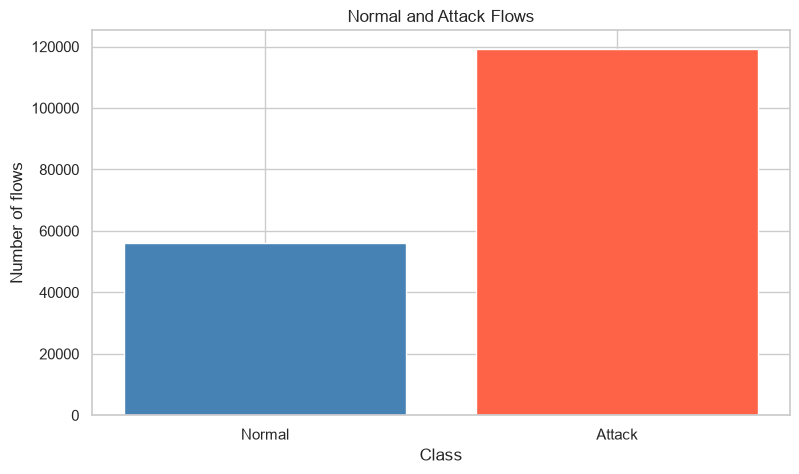

,number of flows
attack_cat,
Normal,56000
Generic,40000
Exploits,33393
Fuzzers,18184
DoS,12264
Reconnaissance,10491
Analysis,2000
Backdoor,1746
Shellcode,1133


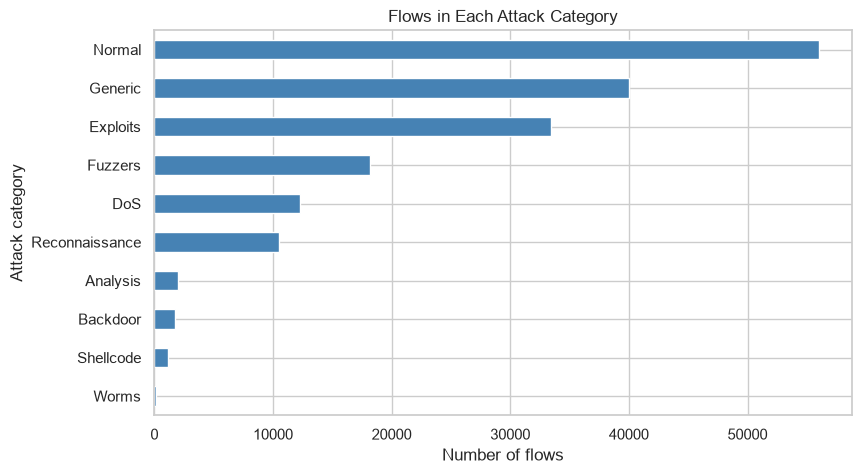

In [5]:
# EDA QUESTION 1: Is the binary target balanced?

# WHY: If one class is much larger, accuracy alone can be misleading.

# LOOK FOR: Compare the number of normal flows with the number of attack flows.

label_counts = build["label"].value_counts()

label_counts = label_counts.sort_index()



print("0 = Normal, 1 = Attack")

display(label_counts.to_frame(name="number of flows"))



# A bar chart makes a class-size difference easier to see than a table.

label_names = ["Normal", "Attack"]

colors = ["steelblue", "tomato"]



plt.bar(label_names, label_counts.values, color=colors)

plt.title("Normal and Attack Flows")

plt.xlabel("Class")

plt.ylabel("Number of flows")

plt.show()



# EDA QUESTION 2: Are all attack types equally common?

# WHY: A model may learn common attacks well but struggle with rare attacks.

# LOOK FOR: Which attack categories dominate? Which have very few examples?

attack_counts = build["attack_cat"].value_counts()

display(attack_counts.to_frame(name="number of flows"))



# A horizontal chart leaves enough room for category names.

attack_counts.sort_values().plot(kind="barh", color="steelblue")

plt.title("Flows in Each Attack Category")

plt.xlabel("Number of flows")

plt.ylabel("Attack category")

plt.show()

---
## 6 Explore Numerical Features

The plots use a reproducible display sample. They include linear and log views because `dur`, bytes, loads, rates, and timing fields are strongly skewed and contain legitimate zeros.

,dur,spkts,dpkts,sbytes,dbytes
count,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05
mean,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04
std,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05
min,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00
25%,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00
50%,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02
75%,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03
max,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07


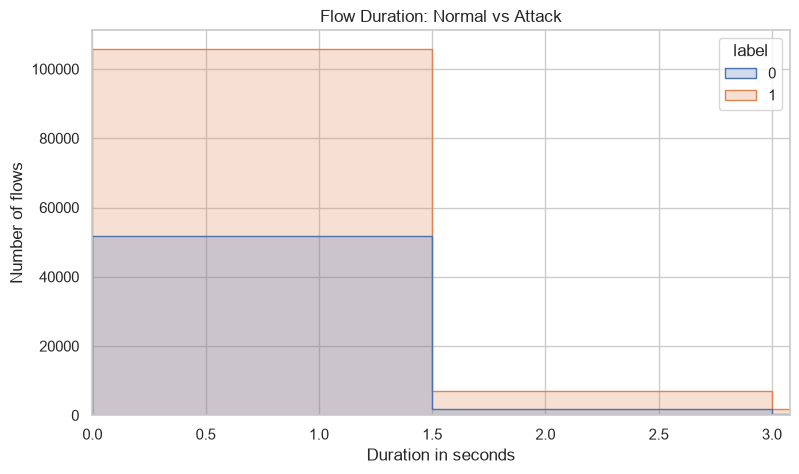

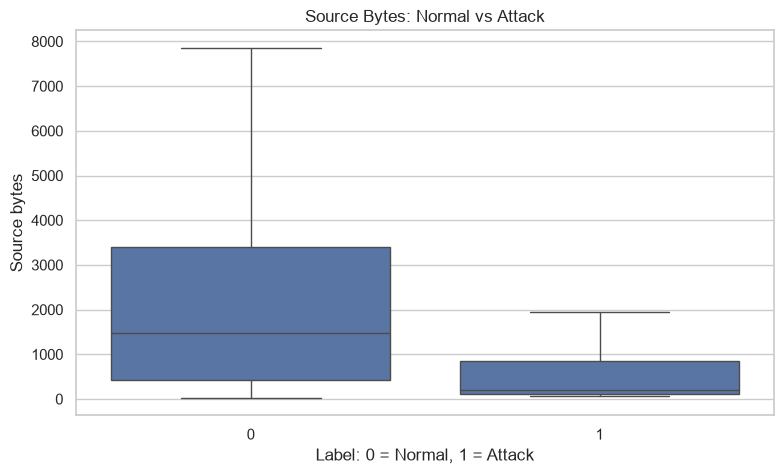

In [6]:
# EDA QUESTION 1: What are typical values for important numeric columns?

# WHY: We need to understand the scale and spread before creating features.

# LOOK FOR in describe():

# - mean and 50% (median) far apart may indicate a skewed distribution;

# - a very large max may indicate outliers;

# - different scales may affect some machine-learning models.

numeric_columns = ["dur", "spkts", "dpkts", "sbytes", "dbytes"]

numeric_summary = build[numeric_columns].describe()

display(numeric_summary)



# EDA QUESTION 2: Does flow duration look different for attacks?

# WHY: A visible class difference suggests duration may be a useful model feature.

# LOOK FOR: Do the two distributions have different centers or shapes?

# We stop the x-axis at the 95th percentile because a few very long flows

# would compress most values into a tiny area of the plot.

duration_limit = build["dur"].quantile(0.95)



sns.histplot(

    data=build,

    x="dur",

    hue="label",

    bins=40,

    element="step",

)

plt.xlim(0, duration_limit)

plt.title("Flow Duration: Normal vs Attack")

plt.xlabel("Duration in seconds")

plt.ylabel("Number of flows")

plt.show()



# EDA QUESTION 3: Does source traffic volume differ by class?

# WHY: Bytes may help separate normal and attack behavior.

# LOOK FOR: Compare the median line and the height of each box.

# We hide individual outlier points so the boxes remain readable.

sns.boxplot(data=build, x="label", y="sbytes", showfliers=False)

plt.title("Source Bytes: Normal vs Attack")

plt.xlabel("Label: 0 = Normal, 1 = Attack")

plt.ylabel("Source bytes")

plt.show()

---
## 7 Explore Categorical Features

Protocol, service, and connection state carry operational meaning. Frequency alone is insufficient: target rate must be shown with count support so tiny groups do not look deceptively certain.

,number of flows
proto,
tcp,79946
udp,63283
unas,12084
arp,2859
ospf,2595
sctp,1150
any,300
gre,225
ipv6,201


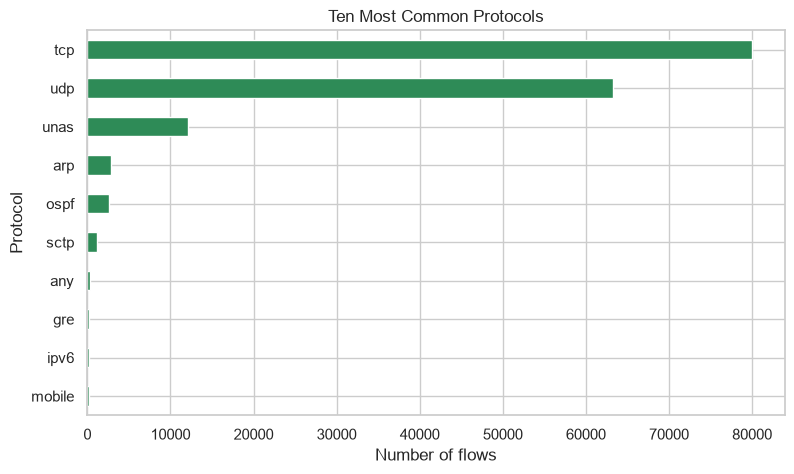

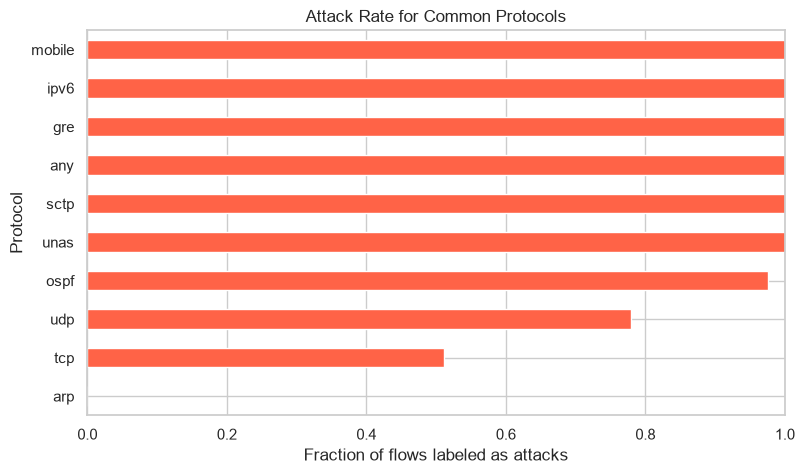

In [7]:
# EDA QUESTION 1: Which protocols are common enough to study?

# WHY: Categories with many rows give more reliable patterns than rare categories.

# LOOK FOR: Which protocols account for most of the network flows?

protocol_counts = build["proto"].value_counts()

top_protocols = protocol_counts.head(10)



display(top_protocols.to_frame(name="number of flows"))



# Plot only the ten most common protocols so the chart stays readable.

top_protocols.sort_values().plot(kind="barh", color="seagreen")

plt.title("Ten Most Common Protocols")

plt.xlabel("Number of flows")

plt.ylabel("Protocol")

plt.show()



# EDA QUESTION 2: Do common protocols have different attack rates?

# WHY: Protocol may be useful to the model if attack rates differ across protocols.

# LOOK FOR: Bars near 1 are mostly attacks; bars near 0 are mostly normal.

# CAUTION: This is an association in this dataset, not proof that a protocol is bad.

protocol_attack_rate = build.groupby("proto")["label"].mean()

protocol_attack_rate = protocol_attack_rate.loc[top_protocols.index]

protocol_attack_rate = protocol_attack_rate.sort_values()



protocol_attack_rate.plot(kind="barh", color="tomato")

plt.title("Attack Rate for Common Protocols")

plt.xlabel("Fraction of flows labeled as attacks")

plt.ylabel("Protocol")

plt.xlim(0, 1)

plt.show()

---
## 8 Analyze Feature Relationships

Correlation is descriptive, not causal. Pearson emphasizes linear association; Spearman emphasizes monotonic rank association; mutual information can detect broader dependence.

,dur,spkts,dpkts,sbytes,dbytes,label
dur,1.00,0.25,0.18,0.20,0.14,0.04
spkts,0.25,1.00,0.39,0.96,0.21,-0.05
dpkts,0.18,0.39,1.00,0.19,0.97,-0.12
sbytes,0.20,0.96,0.19,1.00,0.01,0.02
dbytes,0.14,0.21,0.97,0.01,1.00,-0.08
label,0.04,-0.05,-0.12,0.02,-0.08,1.00


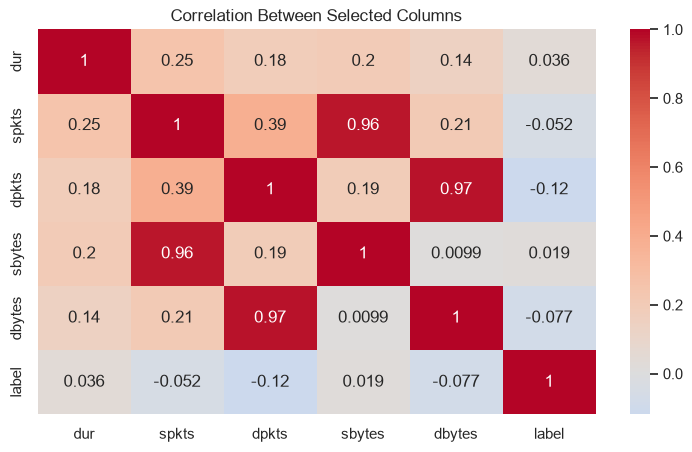

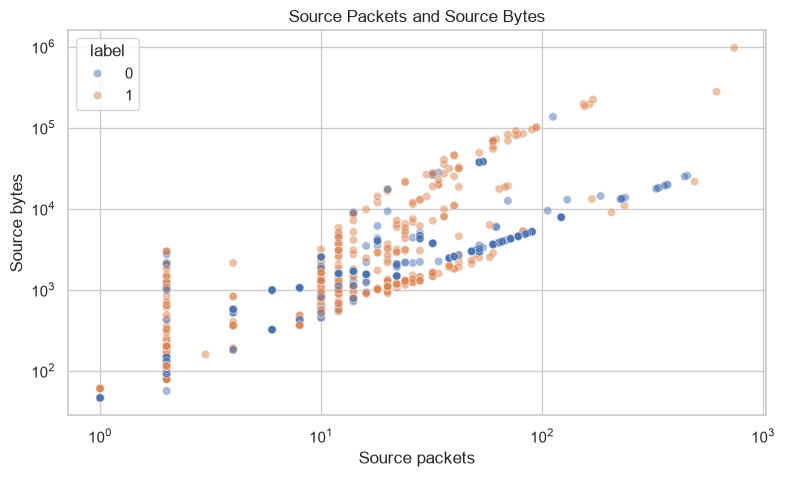

In [8]:
# EDA QUESTION 1: Which numeric columns contain similar information?

# WHY: Strongly correlated features may be measuring the same behavior.

# LOOK FOR: Values near 1 move together; values near -1 move in opposite directions;

# values near 0 have little linear relationship.

correlation_columns = ["dur", "spkts", "dpkts", "sbytes", "dbytes", "label"]

correlations = build[correlation_columns].corr()



display(correlations.round(2))



# The heatmap uses color to make strong relationships easy to spot.

sns.heatmap(correlations, annot=True, cmap="coolwarm", center=0)

plt.title("Correlation Between Selected Columns")

plt.show()



# EDA QUESTION 2: Why might packet count and byte count be related?

# WHY: A scatter plot shows the relationship row by row, which a single

# correlation number cannot show.

# LOOK FOR: Do points form a pattern? Do normal and attack points occupy

# different areas? Could packets and bytes be combined into a new feature?



# Plot a sample because drawing every row would be slow and visually crowded.

plot_sample = build.sample(n=2000, random_state=SEED)



sns.scatterplot(

    data=plot_sample,

    x="spkts",

    y="sbytes",

    hue="label",

    alpha=0.5,

)

plt.title("Source Packets and Source Bytes")

plt.xlabel("Source packets")

plt.ylabel("Source bytes")



# Log scales make both small and large values visible on the same chart.

plt.xscale("log")

plt.yscale("log")

plt.show()



# FEATURE-ENGINEERING THOUGHT:

# The plots suggest that source and destination traffic should be considered

# together. In the next section, we create totals and bytes per packet.

---

## 9 Create Simple Features



Feature engineering means using existing columns to create useful new columns.



We will create three features that are easy to explain:



1. **Total bytes:** source bytes + destination bytes

2. **Total packets:** source packets + destination packets

3. **Bytes per packet:** total bytes / total packets

In [9]:
# FEATURE IDEA 1: Measure the complete traffic volume in both directions.

# WHY: Looking only at source bytes ignores data sent back by the destination.

# EXPECTATION: Total bytes may separate flows better than either direction alone.

data = build.copy()

data["total_bytes"] = data["sbytes"] + data["dbytes"]



# FEATURE IDEA 2: Measure the complete packet volume in both directions.

# WHY: One flow includes source and destination packets.

data["total_packets"] = data["spkts"] + data["dpkts"]



# FEATURE IDEA 3: Measure the average amount of data carried by each packet.

# WHY: Two flows can have the same total bytes but use very different numbers

# of packets. That difference may represent different network behavior.



# Before dividing, check whether any denominator is zero.

zero_packet_rows = (data["total_packets"] == 0).sum()

print("Rows with zero total packets:", zero_packet_rows)



# Division by zero is undefined. Replace zero with 1 only for this calculation.

# The original total_packets column is not changed.

safe_packet_count = data["total_packets"].replace(0, 1)

data["bytes_per_packet"] = data["total_bytes"] / safe_packet_count



# SANITY CHECK: Display original columns beside the new features.

# LOOK FOR: Verify the addition and division manually for the first few rows.

feature_columns = [

    "sbytes",

    "dbytes",

    "total_bytes",

    "spkts",

    "dpkts",

    "total_packets",

    "bytes_per_packet",

]



display(data[feature_columns].head())

Rows with zero total packets: 0


,sbytes,dbytes,total_bytes,spkts,dpkts,total_packets,bytes_per_packet
0,258,172,430,6,4,10,43.000000
1,734,42014,42748,14,38,52,822.076923
2,364,13186,13550,8,16,24,564.583333
3,628,770,1398,12,12,24,58.250000
4,534,268,802,10,6,16,50.125000


---

## 10 Explore the New Features



Check whether the engineered features look different for normal and attack traffic. A useful feature may help a model separate the two classes.

,total_bytes,total_packets,bytes_per_packet
count,1.753410e+05,175341.000000,175341.000000
mean,2.377376e+04,39.268254,173.200698
std,2.273279e+05,206.566369,215.120631
min,2.800000e+01,1.000000,28.000000
25%,1.140000e+02,2.000000,57.000000
50%,8.020000e+02,4.000000,91.500000
75%,3.184000e+03,24.000000,137.550000
max,1.472678e+07,12628.000000,1504.000000


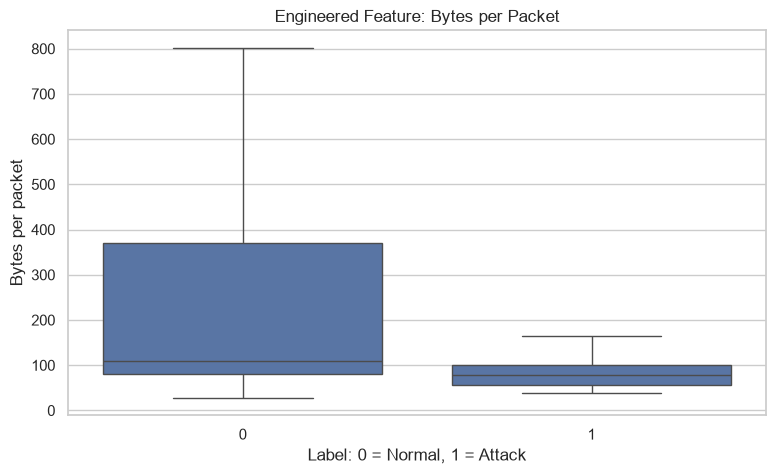

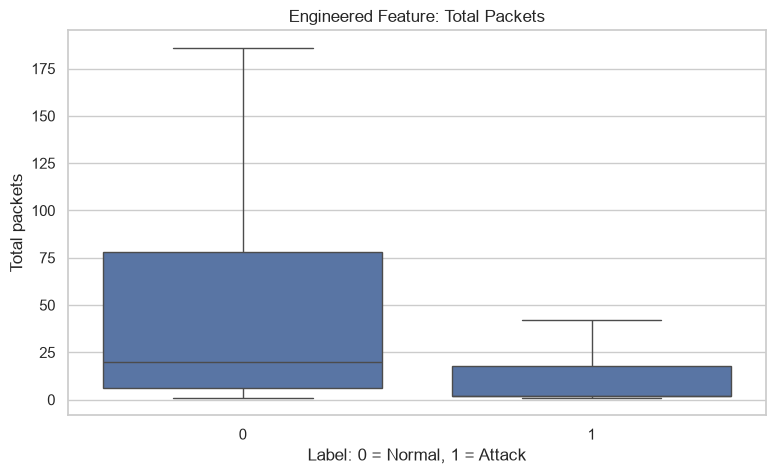

In [10]:
# CHECK 1: Did feature engineering create reasonable values?

# WHY: A formula can run without errors and still produce unrealistic results.

# LOOK FOR: Negative values, extremely large maxima, or unexpected missing values.

new_features = ["total_bytes", "total_packets", "bytes_per_packet"]

display(data[new_features].describe())



# CHECK 2: Does bytes_per_packet differ between the target classes?

# WHY: A feature is promising when its distribution changes between normal

# and attack traffic. It does not need to separate the classes perfectly.

# LOOK FOR: Compare the median lines and the boxes for labels 0 and 1.

sns.boxplot(

    data=data,

    x="label",

    y="bytes_per_packet",

    showfliers=False,

)

plt.title("Engineered Feature: Bytes per Packet")

plt.xlabel("Label: 0 = Normal, 1 = Attack")

plt.ylabel("Bytes per packet")

plt.show()



# CHECK 3: Does total packet volume differ between the target classes?

# WHY: If the groups differ, total_packets may help the model make decisions.

# LOOK FOR: A difference in center, spread, or both.

sns.boxplot(

    data=data,

    x="label",

    y="total_packets",

    showfliers=False,

)

plt.title("Engineered Feature: Total Packets")

plt.xlabel("Label: 0 = Normal, 1 = Attack")

plt.ylabel("Total packets")

plt.show()



# DECISION: Keep these features for the first model because they are available

# when a flow ends, have clear meanings, and may help separate the classes.

---

## 11 Prepare Data for a Model



Choose a small set of understandable features. Text columns must be converted to 0/1 columns before a scikit-learn model can use them.

In [11]:
# Select a small set of original and engineered features

model_features = [

    "dur",

    "sbytes",

    "dbytes",

    "spkts",

    "dpkts",

    "total_bytes",

    "total_packets",

    "bytes_per_packet",

    "proto",

    "service",

    "state",

]



X = data[model_features]

y = data["label"]



# Convert text categories into numeric 0/1 columns

X = pd.get_dummies(X, columns=["proto", "service", "state"])



# Put 80% of rows in training and 20% in validation

X_train, X_validation, y_train, y_validation = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=SEED,

    stratify=y,

)



print("Training rows:", len(X_train))

print("Validation rows:", len(X_validation))

print("Columns after converting text:", X_train.shape[1])

Training rows: 140272
Validation rows: 35069
Columns after converting text: 163


---

## 12 Train One Decision Tree



A shallow decision tree is quick to train and easy to explain. `max_depth=5` limits the tree to reduce overfitting.

In [12]:
# Create the model

model = DecisionTreeClassifier(

    max_depth=5,

    random_state=SEED,

)



# Learn patterns from the training data

model.fit(X_train, y_train)



print("Model training complete")

Model training complete


---

## 13 Evaluate the Model



Predict the validation rows, then compare the predictions with the known labels.

              precision    recall  f1-score   support

      Normal       0.98      0.75      0.85     11200
      Attack       0.89      0.99      0.94     23869

    accuracy                           0.91     35069
   macro avg       0.94      0.87      0.89     35069
weighted avg       0.92      0.91      0.91     35069



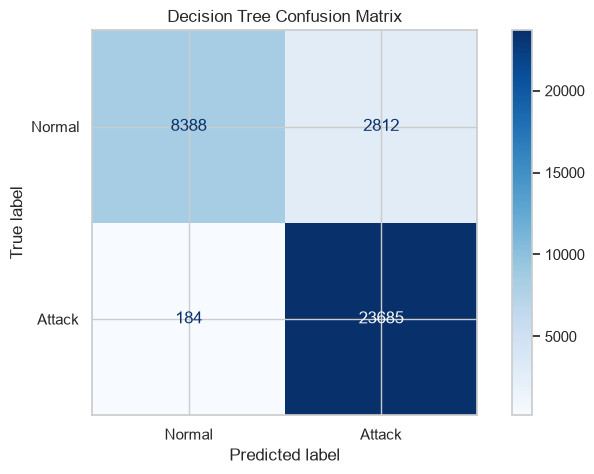

In [13]:
# Predict labels for data the model did not train on

validation_predictions = model.predict(X_validation)



# Print precision, recall, and F1 score for each class

report = classification_report(

    y_validation,

    validation_predictions,

    target_names=["Normal", "Attack"],

)

print(report)



# Draw the confusion matrix

ConfusionMatrixDisplay.from_predictions(

    y_validation,

    validation_predictions,

    display_labels=["Normal", "Attack"],

    cmap="Blues",

)

plt.title("Decision Tree Confusion Matrix")

plt.show()

---

## 14 Which Features Did the Tree Use?



Feature importance shows which columns contributed most to this decision tree. Importance does not prove that a feature causes attacks.

,importance
state_INT,0.357743
dur,0.311242
proto_arp,0.092756
sbytes,0.090665
bytes_per_packet,0.049561
dbytes,0.044807
spkts,0.024675
total_bytes,0.014564
proto_sctp,0.011313
proto_udp,0.002588


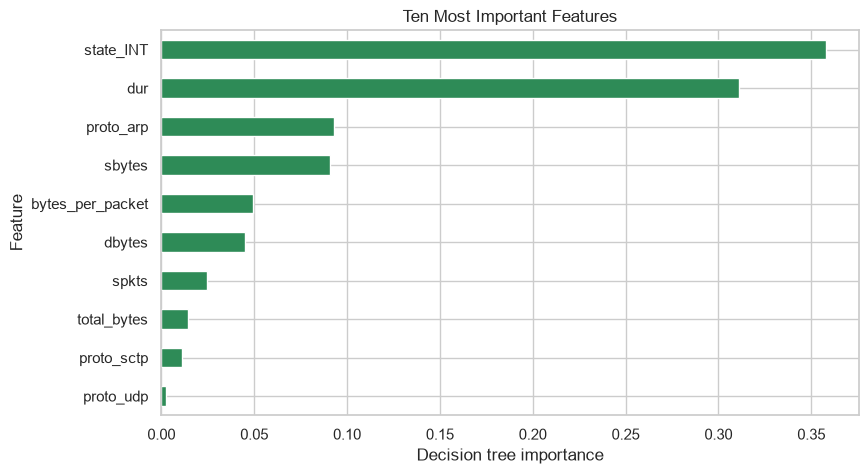

In [14]:
# Match each feature name with its importance score

feature_importance = pd.Series(

    model.feature_importances_,

    index=X_train.columns,

)



# Keep the ten most important features

top_features = feature_importance.sort_values(ascending=False).head(10)

display(top_features.to_frame(name="importance"))



# Draw the important features

top_features.sort_values().plot(kind="barh", color="seagreen")

plt.title("Ten Most Important Features")

plt.xlabel("Decision tree importance")

plt.ylabel("Feature")

plt.show()